# 02 — Feature engineering: *From PGN to 77 features*

Notebook 01 showed that a single game *contains* rating signal. This notebook shows **how we
extract it**: how a raw PGN movetext (SAN moves plus the stored `[%eval]` and `[%clk]`
annotations) becomes the 77-number feature vector the model uses.

**Three points:**

1. **Move-quality features rest on Lichess's own formulas.** Win%, per-move Accuracy% and the
   inaccuracy / mistake / blunder thresholds are transcribed from Lichess's source (`lila` /
   `scalachess`) and pinned by unit tests (`tests/test_features.py`).
2. **Absence is encoded as information, not as zero.** `NaN` means *not observable*, `0` is a real
   zero or an exposure count, and explicit `has_*` flags mark which blocks exist. A game that never
   reached an endgame is not "a game with zero endgame errors".
3. **No feature uses the opponent's rating, identity or move statistics** (the leakage guard from
   notebook 01, §8). Game-level context — result, length, opening code, time control — is shared by
   both players of a game.

We rebuild one real game move by move with the same `src.features` functions the pipeline uses,
and check that the result matches `extract_player_features` exactly.

In [1]:
# --- Setup: paths, style, and the shared save-and-show helper -------------------------------
import sys, json, warnings
from pathlib import Path

# Make `import src...` work whether the notebook is run from notebooks/ or the repo root.
REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from src.config import load_config
from src.plotting import set_style, save_fig
import io
import chess, chess.pgn
# The verified pure primitives + the phase-split extractor and two internal helpers. The by-hand
# worked example reuses _white_cp / _parse_time_control so it is faithful to what
# extract_player_features does inside, not a re-implementation.
from src.features import (
    win_percent, winning_chances, accuracy_percent, classify_move, game_phase,
    extract_player_features, _white_cp, _parse_time_control,
    BLUNDER_THRESHOLD, MISTAKE_THRESHOLD, INACCURACY_THRESHOLD,
)

warnings.filterwarnings("ignore")          # keep library chatter out of the rendered notebook
cfg = load_config()
set_style()                                 # one house style for every figure
OUT = cfg["outputs"]                        # every data/report path comes from config.yaml
FIGROOT = Path(cfg["paths"]["figures"])
FIG = FIGROOT / "notebook_02_features"                  # this notebook's figure folder (auto-created)
BANDS = cfg["rating_bands"]

def show(path):
    "Display a figure that save_fig() just wrote to reports/figures/."
    display(Image(filename=str(path)))

CLAMP = cfg["eval"]["cp_clamp"]         # evals (and forced mates) clamped to +/-1000 before Win%
START_CP = cfg["eval"]["start_cp"]      # assumed eval of the start position

feats = pd.read_parquet(OUT["features"])
print("features:", feats.shape, "| clamp", CLAMP, "| start_cp", START_CP)

features: (606578, 81) | clamp 1000 | start_cp 15


## 1. The Lichess primitives

Two different scales are used, and the code keeps them apart:

- **Win%** ∈ [0, 100] and **winningChances** ∈ [−1, +1] come from the same logistic map of the
  centipawn evaluation, `winningChances = 2 / (1 + exp(−0.00368208 · cp)) − 1`, with the constant
  from Lichess. Win% = 50 + 50 · winningChances. **Accuracy%** of a move is computed from the
  Win% points it lost, `103.1668 · exp(−0.04354 · winDiff) − 3.1669`, plus Lichess's +1 and a clamp
  to [0, 100] (100 if the move did not lose Win%).
- **Move classification** thresholds the drop in **winningChances** at **0.10 / 0.20 / 0.30**
  (inaccuracy / mistake / blunder), i.e. about 5 / 10 / 15 Win% points — not raw centipawns.

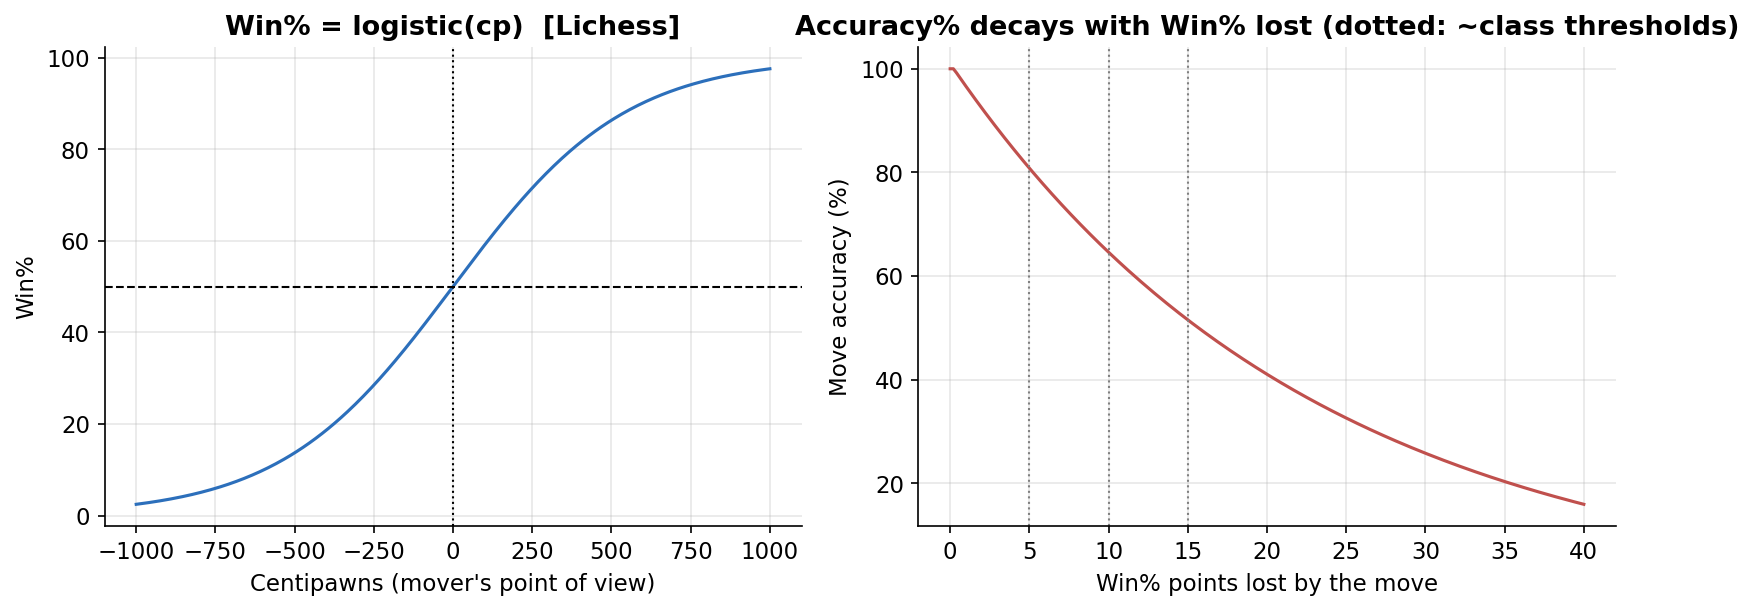

classification thresholds on the winningChances drop (-1..+1 scale):
  inaccuracy >= 0.1   mistake >= 0.2   blunder >= 0.3


,cp,win_percent,winning_chances
0,-800,5.0,-0.900
1,-400,18.7,-0.627
2,-200,32.4,-0.352
3,-100,40.9,-0.182
4,0,50.0,0.000
5,100,59.1,0.182
6,200,67.6,0.352
7,400,81.3,0.627
8,800,95.0,0.900


In [2]:
cp = np.linspace(-1000, 1000, 400)
wpct = np.array([win_percent(c, CLAMP) for c in cp])
wdiff = np.linspace(0, 40, 200)                       # Win% points lost by a move
acc = np.array([accuracy_percent(60.0, 60.0 - d) for d in wdiff])   # accuracy depends only on the drop

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
ax1.plot(cp, wpct, color="#2c6fbb")
ax1.axhline(50, color="k", ls="--", lw=1); ax1.axvline(0, color="k", ls=":", lw=1)
ax1.set(xlabel="Centipawns (mover's point of view)", ylabel="Win%", title="Win% = logistic(cp)  [Lichess]")
ax2.plot(wdiff, acc, color="#c0504d")
for thr in (5, 10, 15):
    ax2.axvline(thr, color="0.5", ls=":", lw=1)
ax2.set(xlabel="Win% points lost by the move", ylabel="Move accuracy (%)",
        title="Accuracy% decays with Win% lost (dotted: ~class thresholds)")
fig.tight_layout()
show(save_fig(fig, "feat_primitives", FIG))

print("classification thresholds on the winningChances drop (-1..+1 scale):")
print(f"  inaccuracy >= {INACCURACY_THRESHOLD}   mistake >= {MISTAKE_THRESHOLD}   blunder >= {BLUNDER_THRESHOLD}")
demo = pd.DataFrame({"cp": [-800, -400, -200, -100, 0, 100, 200, 400, 800]})
demo["win_percent"] = demo["cp"].map(lambda c: round(win_percent(c, CLAMP), 1))
demo["winning_chances"] = demo["cp"].map(lambda c: round(winning_chances(c, CLAMP), 3))
display(demo)

**Reading it.** The Win% curve is steepest near equality: a 100-centipawn swing around 0 moves
Win% much more than the same swing when already ±600. That is why accuracy is measured in Win%,
not raw centipawns — losing 100 cp in a balanced position is a real error, losing 100 cp while a
queen up hardly matters. Accuracy% then decays smoothly as a move loses Win%.

## 2. A worked example: one game, move by move

We pick one real game deterministically — a white-side instance with an opening, a middlegame, an
endgame, a clock scramble and at least one blunder — and replay it the way
`extract_player_features` does: push each move, read the evaluation stored *after* it, turn it to
the mover's point of view, and score the move.

In [3]:
# Deterministic pick. Keep this filter identical to scripts/make_share_bundle.py (the slim data
# bundle keeps the PGN of these candidates).
cand = feats[(feats.color == "white") & (feats.has_endgame == 1) & (feats.has_scramble == 1)
             & feats.game_plies.between(60, 90) & (feats.blunder_count >= 1)].sort_values("game_id")
ex = cand.iloc[0]
GID, COLOR = ex["game_id"], ex["color"]

meta_cols = ["game_id", "white_elo", "black_elo", "result", "eco", "opening", "time_control", "movetext"]
gc = pd.read_parquet(OUT["games_clean"], columns=meta_cols)
g = gc[gc.game_id == GID].iloc[0]

game = chess.pgn.read_game(io.StringIO(g["movetext"]))
base, inc = _parse_time_control(g["time_control"])
print("game     : one game from the sample (its id is not printed)")
print(f"ratings  : white {g['white_elo']} vs black {g['black_elo']}  ->  {g['result']}")
print(f"opening  : {g['eco']}  {g['opening']}")
print(f"control  : {g['time_control']}  (base={base}s inc={inc}s)   we describe: {COLOR} (rating {ex['rating']})")

game     : one game from the sample (its id is not printed)
ratings  : white 1915 vs black 1907  ->  1-0
opening  : C23  Bishop's Opening: Boi Variation
control  : 180+0  (base=180s inc=0s)   we describe: white (rating 1915)


In [4]:
# Replay for our player with the SAME primitives + phase logic as src.features. The eval stored on a
# move is the eval of the position AFTER it (white POV); "before" is the previous ply's eval.
want_white = (COLOR == "white")
board = game.board()
prev_white_cp = START_CP
rows = []
for node in game.mainline():
    move = node.move
    mover_white = board.turn                 # side to move BEFORE the push == the mover
    san = board.san(move)
    board.push(move)
    after_w = _white_cp(node.eval(), CLAMP)  # white-POV cp after the move (mate folded, clamped)
    if mover_white == want_white and after_w is not None and prev_white_cp is not None:
        mover_after = after_w if want_white else -after_w
        mover_before = prev_white_cp if want_white else -prev_white_cp
        wb, wa = win_percent(mover_before, CLAMP), win_percent(mover_after, CLAMP)
        rows.append({
            "ply": node.ply(),
            "phase": game_phase(node.ply(), board, cfg),
            "move": san,
            "cp_after": mover_after,
            "win_before": round(wb, 1),
            "win_after": round(wa, 1),
            "cpl": max(0.0, mover_before - mover_after),
            "accuracy": round(accuracy_percent(wb, wa), 1),
            "class": classify_move(winning_chances(mover_before, CLAMP), winning_chances(mover_after, CLAMP)),
        })
    prev_white_cp = after_w

movetable = pd.DataFrame(rows)
print(f"{len(movetable)} scored moves for {COLOR}. Worst 6 by centipawn loss:")
display(movetable.sort_values("cpl", ascending=False).head(6))
print("\nFirst 10 scored moves:")
display(movetable.head(10))

44 scored moves for white. Worst 6 by centipawn loss:


,ply,phase,move,cp_after,win_before,win_after,cpl,accuracy,class
36,73,endgame,d5,16,70.4,51.5,219.0,43.1,blunder
41,83,endgame,Ke4,39,70.1,53.6,193.0,48.0,blunder
27,55,endgame,R7h4,51,69.6,54.7,174.0,51.7,mistake
7,15,opening,exd5,-250,41.2,28.5,153.0,57.2,mistake
28,57,endgame,Ka2,45,67.2,54.1,150.0,56.2,mistake
17,35,middlegame,Qf3,324,83.5,76.7,117.0,74.5,inaccuracy



First 10 scored moves:


,ply,phase,move,cp_after,win_before,win_after,cpl,accuracy,class
0,1,opening,e4,18,51.4,51.7,0.0,100.0,ok
1,3,opening,Bc4,3,51.9,50.3,18.0,93.8,ok
2,5,opening,Nf3,10,51.2,50.9,3.0,99.8,ok
3,7,opening,d3,16,53.4,51.5,21.0,92.7,ok
4,9,opening,Ng5,-50,51.7,45.4,69.0,76.1,inaccuracy
5,11,opening,h4,-137,47.7,37.6,112.0,64.4,mistake
6,13,opening,Nc3,-114,36.3,39.7,0.0,100.0,ok
7,15,opening,exd5,-250,41.2,28.5,153.0,57.2,mistake
8,17,opening,Bb3,-243,27.7,29.0,0.0,100.0,ok
9,19,opening,a3,-302,29.2,24.8,61.0,83.0,ok


**Reading the move table.** Each row is one of our player's moves: the evaluation after it (mover's
point of view), Win% before and after, the centipawn loss (`cpl`, floored at 0 — a move that
*improves* the evaluation is not penalised), the move's accuracy and its class. The worst moves
are the ones that lose a large share of Win% at once. The aggregates summarise this table:
mean/median/max CPL, mean accuracy, counts and rates of inaccuracies/mistakes/blunders — overall
*and* separately per phase.

In [5]:
# Cross-check: the by-hand aggregates must match extract_player_features exactly.
fv = extract_player_features(game, want_white, cfg, increment=inc, base_seconds=base,
                             player_result=ex["result"])
manual_cpl_mean = movetable["cpl"].mean()
manual_blunders = int((movetable["class"] == "blunder").sum())
print(f"cpl_mean   : by-hand {manual_cpl_mean:.4f}   |   extract_player_features {fv['cpl_mean']:.4f}")
print(f"blunders   : by-hand {manual_blunders}         |   extract_player_features {int(fv['blunder_count'])}")
print(f"n_moves    : by-hand {len(movetable)}          |   extract_player_features {int(fv['n_moves'])}")
assert abs(manual_cpl_mean - fv["cpl_mean"]) < 1e-6 and manual_blunders == int(fv["blunder_count"])
assert abs(fv["cpl_mean"] - ex["cpl_mean"]) < 1e-6        # ...and the stored feature row
print("\nMATCH: the notebook replay reproduces src.features and the stored feature row.")

cpl_mean   : by-hand 47.0000   |   extract_player_features 47.0000
blunders   : by-hand 2         |   extract_player_features 2
n_moves    : by-hand 44          |   extract_player_features 44

MATCH: the notebook replay reproduces src.features and the stored feature row.


In [6]:
# Part of the feature vector this game produces, grouped by phase.
def phase_block(prefix):
    keys = [f"{prefix}n_moves", f"{prefix}cpl_mean", f"{prefix}cpl_max", f"{prefix}acc_mean",
            f"{prefix}blunder_count", f"{prefix}blunder_rate"]
    return {k.replace(prefix, ""): fv.get(k) for k in keys}

blocks = pd.DataFrame({
    "overall":    phase_block(""),
    "opening":    phase_block("opening_"),
    "middlegame": phase_block("middlegame_"),
    "endgame":    phase_block("endgame_"),
}).T
display(blocks.round(2))
print("presence flags:", {k: fv[k] for k in ["has_opening", "has_middlegame", "has_endgame", "has_clock", "has_scramble"]})

,n_moves,cpl_mean,cpl_max,acc_mean,blunder_count,blunder_rate
overall,44.0,47.00,219.0,87.21,2.0,0.05
opening,15.0,39.47,153.0,88.77,0.0,0.00
middlegame,5.0,38.80,117.0,91.59,0.0,0.00
endgame,24.0,53.42,219.0,85.32,2.0,0.08


presence flags: {'has_opening': 1, 'has_middlegame': 1, 'has_endgame': 1, 'has_clock': 1, 'has_scramble': 1}


## 3. Phase splitting

Move quality is aggregated per phase because the opening separates players far more than the
endgame does (notebook 01). The boundaries are pragmatic (`config.yaml → phases`):

- **Opening**: plies 1–30 (about 15 moves each).
- **Endgame**: once the non-pawn, non-king pieces left on the board (both sides) number 6 or fewer.
- **Middlegame**: everything in between.

Our example game's evaluation over time, coloured by phase:

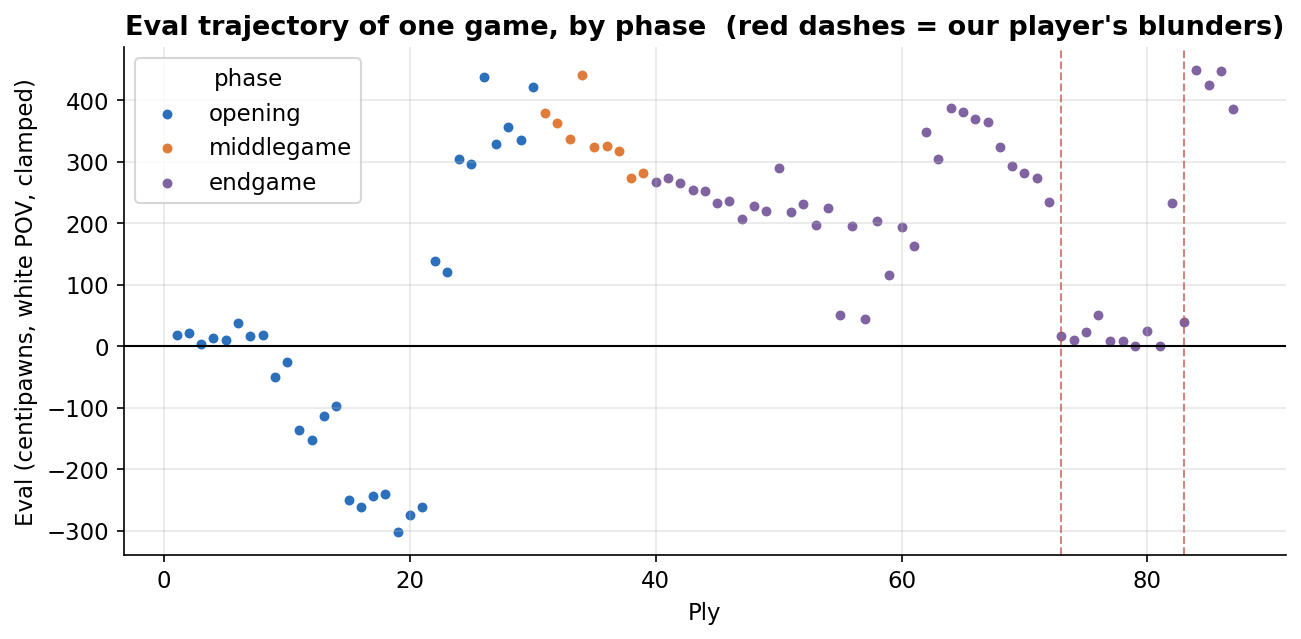

In [7]:
board = game.board()
plies, cps, phases = [], [], []
for node in game.mainline():
    board.push(node.move)
    w = _white_cp(node.eval(), CLAMP)
    if w is not None:
        plies.append(node.ply()); cps.append(w); phases.append(game_phase(node.ply(), board, cfg))

plies, cps = np.array(plies), np.array(cps)
colors = {"opening": "#2c6fbb", "middlegame": "#e07b39", "endgame": "#8064a2"}
fig, ax = plt.subplots(figsize=(10, 4.4))
ax.axhline(0, color="k", lw=1)
for ph, col in colors.items():
    m = np.array([p == ph for p in phases])
    if m.any():
        ax.scatter(plies[m], cps[m], s=14, color=col, label=ph)
for _, br in movetable[movetable["class"] == "blunder"].iterrows():
    ax.axvline(br["ply"], color="#c0504d", ls="--", lw=1, alpha=0.7)
ax.set(xlabel="Ply", ylabel="Eval (centipawns, white POV, clamped)",
       title="Eval trajectory of one game, by phase  (red dashes = our player's blunders)")
ax.legend(title="phase")
show(save_fig(fig, "feat_eval_trajectory", FIG))

**Reading it.** The evaluation moves through the three phases; our player's blunders (red) are the
sharp swings against them. Because the model receives per-phase CPL and blunder rates separately,
it can tell a clean opening followed by an endgame collapse from the reverse — a difference a
single overall CPL would blur.

## 4. The missing-value contract

The rule:

> **`NaN` means *not observable*. `0` is reserved for a true zero — an exposure count
> (`{phase}_n_moves`, `n_timed_moves`) or a genuinely computed zero. A phase that never happened
> gets `n_moves = 0` and `NaN` for *every* other aggregate of that phase, including the error
> counts, because a count or rate is only meaningful when the phase was played.** Five presence
> flags (`has_opening`, `has_middlegame`, `has_endgame`, `has_clock`, `has_scramble`) make absence
> directly splittable.

Writing `0` for "no endgame blunders" when there was no endgame would tell the model that the
player played a flawless endgame. LightGBM handles `NaN` natively (it learns which side of a split
missing values go to), so nothing is imputed.

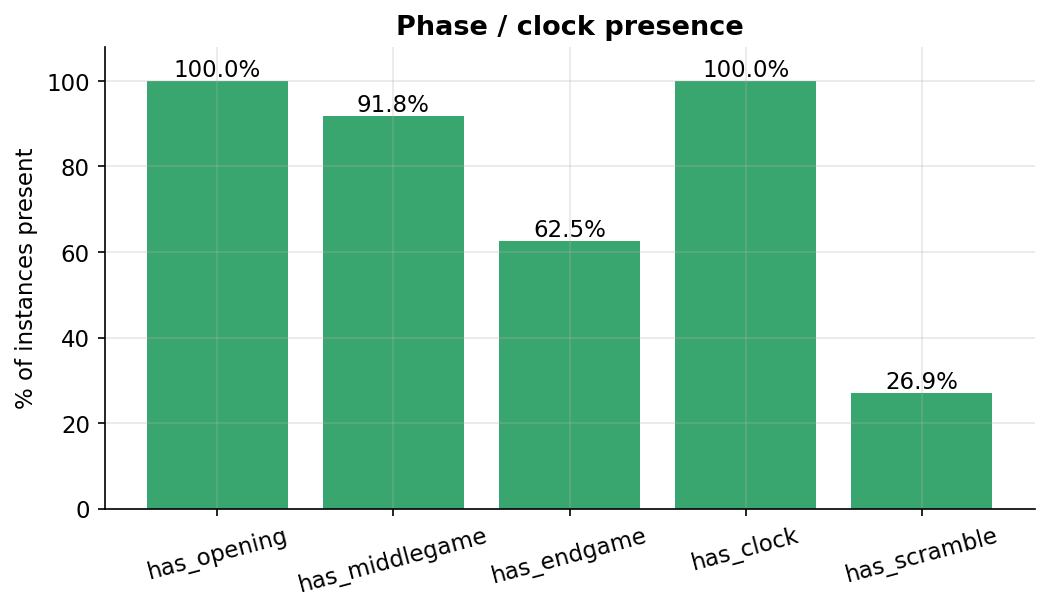

instances with no endgame : 227,446  (37.5%)
  of those, endgame_cpl_mean is NaN     : 100.0%
  of those, endgame_blunder_count is NaN: 100.0%
  has_endgame flag for those rows       : 0 (all zero)


In [8]:
flags = ["has_opening", "has_middlegame", "has_endgame", "has_clock", "has_scramble"]
rates = feats[flags].mean()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(flags, rates.values * 100, color="#3aa66f")
for b, v in zip(bars, rates.values):
    ax.text(b.get_x() + b.get_width() / 2, v * 100, f"{v * 100:.1f}%", ha="center", va="bottom")
ax.set(ylabel="% of instances present", title="Phase / clock presence", ylim=(0, 108))
ax.tick_params(axis="x", rotation=15)
show(save_fig(fig, "feat_presence_flags", FIG))

# Contract check: when the endgame block is absent, every non-count endgame aggregate is NaN.
no_eg = feats[feats["endgame_n_moves"] == 0]
print(f"instances with no endgame : {len(no_eg):,}  ({len(no_eg) / len(feats):.1%})")
print(f"  of those, endgame_cpl_mean is NaN     : {no_eg['endgame_cpl_mean'].isna().mean():.1%}")
print(f"  of those, endgame_blunder_count is NaN: {no_eg['endgame_blunder_count'].isna().mean():.1%}")
print(f"  has_endgame flag for those rows       : {no_eg['has_endgame'].max()} (all zero)")

In [9]:
# A few rows side by side: presence flag, exposure count (a true 0/int), and aggregates (NaN vs value).
mix = pd.concat([
    feats[feats["has_endgame"] == 1].head(3),
    feats[feats["has_endgame"] == 0].head(3),
])[["has_endgame", "endgame_n_moves", "endgame_cpl_mean", "endgame_blunder_count"]]
display(mix.reset_index(drop=True))

,has_endgame,endgame_n_moves,endgame_cpl_mean,endgame_blunder_count
0,1,25,12.68,0.0
1,1,25,26.52,0.0
2,1,10,8.90,0.0
3,0,0,NaN,NaN
4,0,0,NaN,NaN
5,0,0,NaN,NaN


**Reading it.** Every instance has an opening and clock data; about 92% reach a middlegame; only
about 62.5% reach an endgame, so about 37.5% carry `NaN` in their whole endgame block (not `0`).
The table makes the contract concrete: `has_endgame` and `endgame_n_moves` are true zeros, while
`endgame_cpl_mean` and `endgame_blunder_count` are `NaN`.

This encoding was compared with the older mixed 0/NaN scheme on identical grouped splits
(`reports/results.md`, "missing-value encoding A/B", run on an earlier, smaller development
sample of about 59k instances): the two were performance-neutral (ΔMAE +0.5), and the NaN contract
was kept **for correctness**, not for a metric gain.

## 5. Clock features and the scramble block

Move times come from consecutive `[%clk]` readings (`time spent = previous remaining − remaining +
increment`). Besides the ordinary clock features (`move_time_*`, `fast_move_share`,
`time_trouble_share`), a **clock-scramble block** looks only at moves played while the player had
under 30 s left *before* the move. Its headline feature is
`scramble_cpl_delta = scramble_cpl_mean − cpl_mean`: how much worse the player plays when short of
time, relative to their own level in the same game.

instances with a scramble phase (<30 s reached): 163,466  (26.9%)
scramble_cpl_delta  median +8.3 cpl   mean +33.0 cpl   (defined for 99% of them)


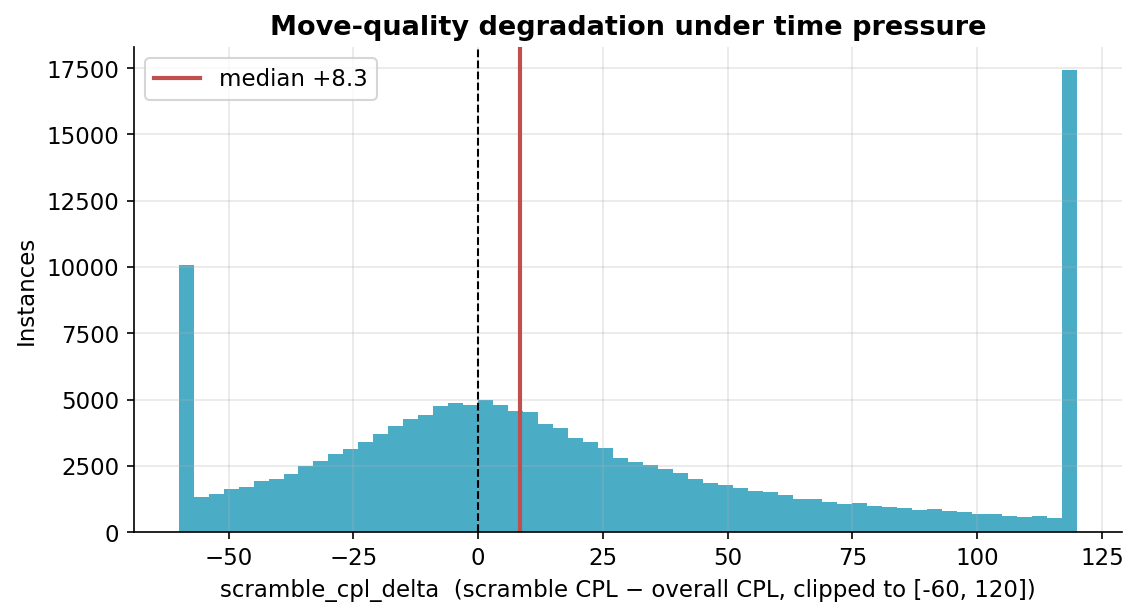

In [10]:
sc = feats[feats["has_scramble"] == 1]
print(f"instances with a scramble phase (<30 s reached): {len(sc):,}  ({len(sc) / len(feats):.1%})")
print(f"scramble_cpl_delta  median {sc['scramble_cpl_delta'].median():+.1f} cpl   mean {sc['scramble_cpl_delta'].mean():+.1f} cpl"
      f"   (defined for {sc['scramble_cpl_delta'].notna().mean():.0%} of them)")

d = sc["scramble_cpl_delta"].clip(-60, 120)
fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.hist(d, bins=60, color="#4bacc6")
ax.axvline(0, color="k", ls="--", lw=1)
ax.axvline(sc["scramble_cpl_delta"].median(), color="#c0504d", lw=2,
           label=f"median {sc['scramble_cpl_delta'].median():+.1f}")
ax.set(xlabel="scramble_cpl_delta  (scramble CPL − overall CPL, clipped to [-60, 120])", ylabel="Instances",
       title="Move-quality degradation under time pressure")
ax.legend()
show(save_fig(fig, "feat_scramble_delta", FIG))

**Reading it.** About 27% of instances reach a scramble. The distribution sits to the right of
zero: the median player loses about **8 more centipawns per move** once under 30 seconds, with a
long right tail (mean about +33) of players who fall apart. Part of this is the game phase rather
than the clock alone — scramble moves come late in the game — but it is a real, measurable
behaviour. Notebook 05 shows that the scramble features nevertheless add almost nothing to the
model (about 0.2 Elo).

## 6. The leakage guard and the final 77 features

No feature uses the opponent's **rating, identity or move statistics** — no opponent rating, no
opponent CPL, no rating gap. (Game-level context such as the result, the game length and the
opening code is shared by both players; it describes the game, not the opponent's strength.) `split_feature_columns` enforces this by *excluding* a
fixed set of non-feature columns and handing the model everything else.

In [11]:
from src.model import split_feature_columns, _NON_FEATURE
from src.evaluate import feature_groups

num, cat = split_feature_columns(feats)
print(f"model features: {len(num)} numeric + {len(cat)} categorical = {len(num) + len(cat)}")
print(f"categorical   : {cat}")
print(f"never a feature: {sorted(_NON_FEATURE)}")

groups = feature_groups(num + cat)
census = pd.DataFrame([(g, len(cols)) for g, cols in groups.items()], columns=["group", "n_features"])
display(census.sort_values("n_features", ascending=False))

model features: 73 numeric + 4 categorical = 77
categorical   : ['result', 'time_control', 'eco', 'color']
never a feature: ['game_id', 'opening', 'opponent_rating', 'rating', 'username']


,group,n_features
0,engine,50
3,style,18
1,clock,8
2,opening,1


**Reading it.** The model sees **77 features**: 73 numeric plus 4 categoricals (`result`,
`time_control`, `eco`, `color`). Five columns are never features: `game_id` and `username`
(identifiers), `rating` (the label), `opening` (free text, superseded by `eco`) and
`opponent_rating` (the leak, attached only for the copy-opponent reference in notebook 03). For
ablations the features are grouped by keyword into **engine** (move quality), **clock**, **opening**
(`eco`) and **style** (everything else: game shape, result, colour, time control, presence flags).
The scramble features fall into several of these groups; notebook 05 ablates them as one block.

The other half of the guard is the split: because a player can appear in many games, every
train / validation / calibration / test split is made **by `username`**
(`grouped_train_val_calib_test`), never by game, so the model cannot memorise a player.

## Takeaways

- **Lichess's own per-move formulas**, unit-tested; the worked example matches
  `extract_player_features` and the stored feature row exactly.
- **A game that ends early is information.** `NaN` = unobservable, `0` = true zero, plus `has_*`
  flags; 37.5% of instances have no endgame block.
- **Time pressure is measurable** (median +8 cpl in a scramble), though it adds little to the model.
- **77 features, none using the opponent's rating, identity or move statistics** (shared game
  context — result, length, opening, time control — is used), and splits grouped by player.

**Next:** notebook 03 sets the reference points the full model must beat — including the
copy-opponent leak that the last two notebooks explained why we exclude.